In [1]:
# Cell 1 — Imports
import numpy as np
import pandas as pd
import xarray as xr
import sys
import matplotlib.pyplot as plt
from pathlib import Path
import glob
sys.path.append(str(Path("../src").resolve()))
from radar_lwc.preprocessing.chirps import combine_chirps
from radar_lwc.preprocessing.get_reflectivity import get_reflectivity
from radar_lwc.preprocessing.clean import drop_duplicate_times
from radar_lwc.preprocessing.align import align_to_reference_time

Load Both Radars

In [2]:
# Cell 2 — Load both
def load_rpg(folder):
    files = sorted(glob.glob(str(Path(folder) / "*ZEN.LV1.nc")))
    ds = xr.open_mfdataset(files, combine="by_coords")    # Combine="by_coords" orders them immediately by coordinates, in this case by the time so it is immediately in structure 7:01...7:02...7:03
    epoch = pd.Timestamp("2001-01-01")
    ds = ds.assign_coords(Time=("Time", epoch + pd.to_timedelta(ds.Time.values, unit="s")))
    ds = drop_duplicate_times(ds)
    return ds

ds_w  = load_rpg("../data/raw/cmtrace/20230928")
ds_ka = load_rpg("../data/raw/cmtrace/20230928_KaBand")

C:\Users\geron\AppData\Local\Temp\ipykernel_22220\2951657530.py:6: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; it can be silenced by converting the values to nanosecond precision ahead of time.
  ds = ds.assign_coords(Time=("Time", epoch + pd.to_timedelta(ds.Time.values, unit="s")))
C:\Users\geron\AppData\Local\Temp\ipykernel_22220\2951657530.py:6: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 

Reflectivities

In [3]:
# Cell 3 — Reflectivities
ze_w  = get_reflectivity(ds_w)
ze_ka = get_reflectivity(ds_ka)

Ranges and Time Coverage

In [4]:
# Cell 4 — Inspect ranges & time coverage  ← KEEP, condensed
print(f"W : {ze_w['range'].values[0]:.1f} → {ze_w['range'].values[-1]:.1f} m  ({ze_w.sizes['range']} gates)")
print(f"Ka: {ze_ka['range'].values[0]:.1f} → {ze_ka['range'].values[-1]:.1f} m  ({ze_ka.sizes['range']} gates)")
identical = np.allclose(ze_w['range'].values, ze_ka['range'].values)
print(f"Ranges identical: {identical}")

# Time coverage
print(f"\nW  : {ze_w.Time.values[0]}  →  {ze_w.Time.values[-1]}  ({ze_w.sizes['Time']} samples)")
print(f"Ka : {ze_ka.Time.values[0]}  →  {ze_ka.Time.values[-1]}  ({ze_ka.sizes['Time']} samples)")

# Temporal resolution
dt_ka = (ze_ka.Time.diff("Time") / np.timedelta64(1,"s")).median().values
dt_w  = (ze_w.Time.diff("Time")  / np.timedelta64(1,"s")).median().values
print(f"\nMedian Δt  W={dt_w:.1f}s   Ka={dt_ka:.1f}s")


W : 111.8 → 11974.8 m  (339 gates)
Ka: 111.8 → 11974.8 m  (339 gates)
Ranges identical: True

W  : 2023-09-28T07:00:04.000000000  →  2023-09-28T14:00:32.000000000  (10441 samples)
Ka : 2023-09-28T07:00:04.000000000  →  2023-09-28T14:00:32.000000000  (10520 samples)

Median Δt  W=1.0s   Ka=1.0s


In [5]:
missing_in_w = np.setdiff1d(ze_ka["Time"].values, ze_w["Time"].values)

print(f"Missing in W: {len(missing_in_w)} time steps")
print(missing_in_w)

Missing in W: 79 time steps
['2023-09-28T12:36:44.000000000' '2023-09-28T13:46:52.000000000'
 '2023-09-28T13:46:53.000000000' '2023-09-28T13:46:54.000000000'
 '2023-09-28T13:46:55.000000000' '2023-09-28T13:46:56.000000000'
 '2023-09-28T13:46:57.000000000' '2023-09-28T13:46:58.000000000'
 '2023-09-28T13:46:59.000000000' '2023-09-28T13:47:00.000000000'
 '2023-09-28T13:47:01.000000000' '2023-09-28T13:47:02.000000000'
 '2023-09-28T13:47:03.000000000' '2023-09-28T13:47:04.000000000'
 '2023-09-28T13:47:05.000000000' '2023-09-28T13:47:06.000000000'
 '2023-09-28T13:47:07.000000000' '2023-09-28T13:47:08.000000000'
 '2023-09-28T13:47:09.000000000' '2023-09-28T13:47:10.000000000'
 '2023-09-28T13:47:11.000000000' '2023-09-28T13:47:12.000000000'
 '2023-09-28T13:47:13.000000000' '2023-09-28T13:47:14.000000000'
 '2023-09-28T13:47:15.000000000' '2023-09-28T13:47:16.000000000'
 '2023-09-28T13:47:17.000000000' '2023-09-28T13:47:18.000000000'
 '2023-09-28T13:47:19.000000000' '2023-09-28T13:47:20.00000000

==================================================================================================================================================

ALIGN TIME

==================================================================================================================================================

In [6]:
# Cell 5 — Common time grid  --> If it is more then a little part that is missing for the time steps

# ze_w_c = align_to_reference_time(
    #da_ref=ze_ka,
    #da_target=ze_w,
    #method="nearest"
#)

#ze_ka_c = ze_ka

In [7]:
# Cell 6 — Range alignment (only if not identical)
#if not identical:
 # ze_ka_c = ze_ka_c.interp(range=ze_w_c["range"])

In [8]:
ze_ka_c = ze_ka.sel(Time=ze_w.Time)      # Both are set to the ze_w  time ; .sel selects only the data whose Time coordinates match the Time coordinates of ze_w.
ze_w_c = ze_w

In [9]:
# Cell 7 — Verify
print(f"After alignment: W={ze_w_c.shape}, Ka={ze_ka_c.shape}")
assert ze_w_c.shape == ze_ka_c.shape, "Shapes still don't match!"
print("✅ Aligned on common (time, range) grid")

After alignment: W=(10441, 339), Ka=(10441, 339)
✅ Aligned on common (time, range) grid


==================================================================================================================================================

PLOT

==================================================================================================================================================

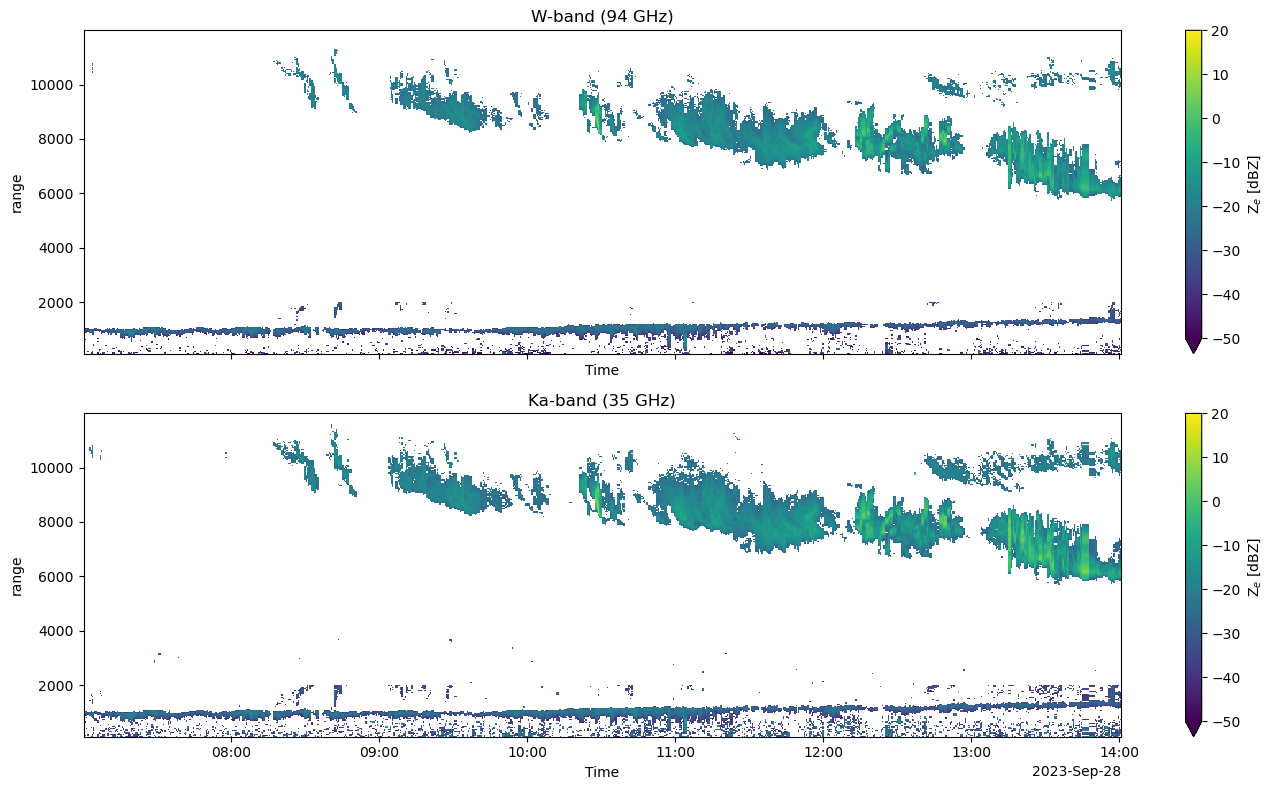

In [10]:
# Cell 8 — Side-by-side plot
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True, sharey=True)
ze_w_c.plot(x="Time", y="range", ax=axes[0], cmap="viridis", vmin=-50, vmax=20, cbar_kwargs={"label": "Z$_e$ [dBZ]"})
axes[0].set_title("W-band (94 GHz)")
ze_ka_c.plot(x="Time", y="range", ax=axes[1], cmap="viridis", vmin=-50, vmax=20, cbar_kwargs={"label": "Z$_e$ [dBZ]"})
axes[1].set_title("Ka-band (35 GHz)")
plt.tight_layout()
plt.show()

(array([1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 1.0000e+00, 1.0000e+00, 4.0000e+00, 3.0000e+00,
        4.0000e+00, 1.5000e+01, 5.0000e+00, 6.0000e+00, 1.1000e+01,
        1.9000e+01, 3.0000e+01, 3.3000e+01, 4.8000e+01, 1.2800e+02,
        3.9900e+02, 8.0400e+02, 1.3650e+03, 2.1560e+03, 3.0060e+03,
        3.9810e+03, 4.7200e+03, 5.5470e+03, 6.1360e+03, 6.5760e+03,
        7.2160e+03, 7.2030e+03, 7.2920e+03, 7.1780e+03, 7.0740e+03,
        6.7960e+03, 6.7490e+03, 6.6410e+03, 6.5770e+03, 6.8460e+03,
        6.8310e+03, 7.2410e+03, 8.0030e+03, 8.8160e+03, 9.9230e+03,
        1.1528e+04, 1.3329e+04, 1.5657e+04, 1.7927e+04, 1.9538e+04,
        2.0238e+04, 2.0058e+04, 1.8738e+04, 1.7327e+04, 1.6038e+04,
        1.4390e+04, 1.3583e+04, 1.2888e+04, 1.2159e+04, 1.1284e+04,
        1.0759e+04, 1.0105e+04, 9.6920e+03, 9.3920e+03, 8.5110e+03,
        7.7640e+03, 6.5390e+03, 5.2700e+03, 4.6230e+03, 3.8790e+03,
        3.5570e+03, 3.1360e+03, 2.8520e+03, 2.38

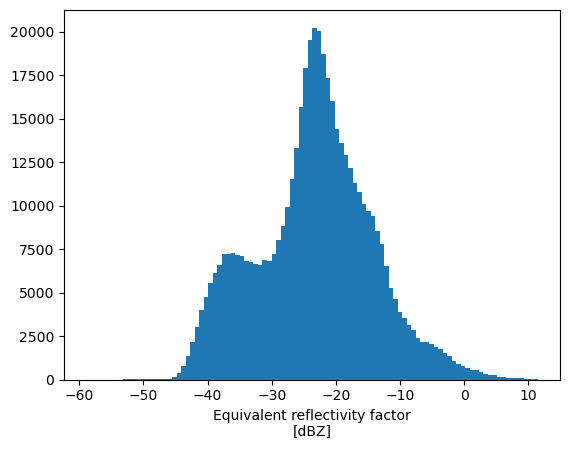

In [11]:
ze_ka.plot.hist(bins=100)

TEMPERATURE

In [12]:
T = ds_w["TProf"]                     # whatever the variable is named
print("Shape:", T.shape)                 # (Time, TAlt)?
print("Dims:", T.dims)
print("Min/Max:", float(T.min()), float(T.max()))
print("First profile (first time, all altitudes):")
print(T.isel(Time=0).values)
print("Altitude coord (if any):")
print(ds_w.coords)  # look for TAltLayer or similar


Shape: (10441, 93)
Dims: ('Time', 'TAlt')
Min/Max: 224.45999145507812 292.6600036621094
First profile (first time, all altitudes):
[289.46    289.395   289.2975  289.13498 288.9725  288.81    288.615
 288.41998 288.225   288.03    287.835   287.63998 287.44498 287.25
 287.055   286.86    286.66498 286.47    286.275   286.08    285.81998
 285.56    285.3     285.03998 284.78    284.52    284.25998 284.
 283.74    283.47998 283.22    282.96    282.69998 282.44    282.18
 281.91998 281.66    281.27    280.88    280.49    280.1     279.71
 279.31998 278.93    278.53998 278.15    277.75998 277.175   276.59
 275.35498 274.77    274.185   273.66498 273.21    272.56    271.91
 271.25998 270.61    269.96    269.31    268.66    268.00998 267.36
 266.71    265.735   264.75998 263.785   262.81    261.835   260.86
 259.88498 259.56    258.25998 256.96    255.65999 254.35999 253.06
 251.76    250.45999 248.51    246.56    244.60999 242.65999 240.70999
 238.76    236.81    234.85999 232.90999 230.959

==================================================================================================================================================

The T Profile Values are interpolated onto the Range grid. First we have to get the altitudes for the Temperature Profile in T_Alts, because Temperature Profile T_Prof only has Indices 1,2,3,.... Afterwards T_Prof uses T_Alts Altitudes and then the Values are interpolated onto the range grid

==================================================================================================================================================

In [13]:
# Physical altitude of radiometer profile
T_alts = ds_w["TAlts"].isel(Time=0).values
assert np.allclose(ds_w["TAlts"].values, T_alts), "TAlts varies in time!"   # T_Alts is only at time 0 and it is compared to all the rest of data in TAlts. If it is not the same, then it will raise an error. This is to ensure that the altitude values are consistent across all time steps.

# Tell xarray these are the heights of TProf  --> I give T_Prof new Altitude Values because it just as 1,2,3,4... as indice instead of actual heights
T_prof = ds_w["TProf"].assign_coords(TAlt=("TAlt", T_alts))

# Interpolate onto radar gates
T_on_range = T_prof.interp(
    TAlt=ze_w_c["range"],
    method="linear"
)

T_on_range.name = "T_cloud"

In [14]:
print(T_on_range.shape)                                # should match ze_w_c.shape
print(f"{float(T_on_range.min()):.1f} → {float(T_on_range.max()):.1f} °K")
# Expect roughly: -60 → +20 °C  for Cabauw autumn

(10441, 339)
224.6 → 291.9 °K


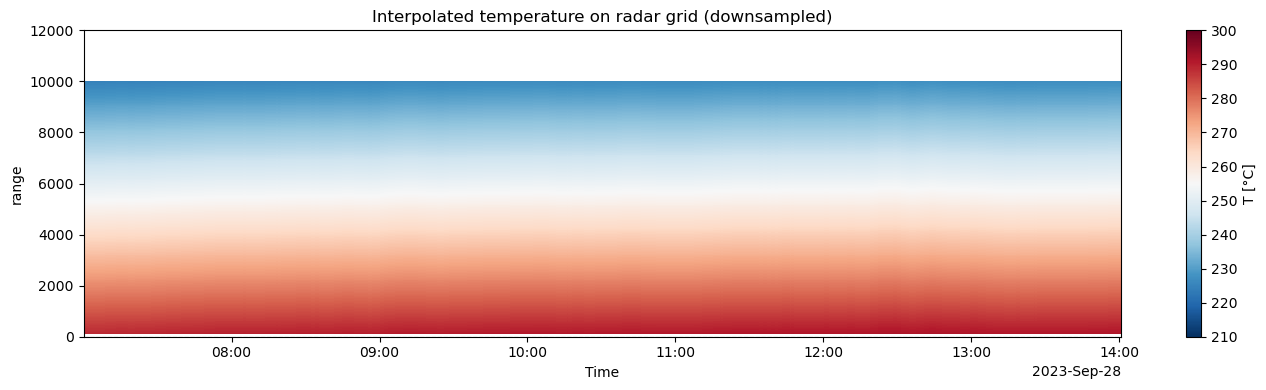

In [15]:

fig, ax = plt.subplots(1, 1, figsize=(14, 4))

T_on_range.isel(Time=slice(0, None, 5)).plot(
    x="Time",
    y="range",
    ax=ax,
    cmap="RdBu_r",
    vmin=210,
    vmax=300,
    cbar_kwargs={"label": "T [°C]"},
)

ax.axhline(0, ls="--", c="k", lw=0.8, alpha=0.5)
ax.set_ylim(0, 12000)
ax.set_title("Interpolated temperature on radar grid (downsampled)")

plt.tight_layout()
plt.show()


LWP FOR DATA SAVING

In [16]:
lwp = ds_w["LWP"]  # adjust name if needed
print(lwp)

<xarray.DataArray 'LWP' (Time: 10441)> Size: 42kB
dask.array<getitem, shape=(10441,), dtype=float32, chunksize=(78,), chunktype=numpy.ndarray>
Coordinates:
  * Time     (Time) datetime64[ns] 84kB 2023-09-28T07:00:04 ... 2023-09-28T14...
Attributes:
    Name:     Liquid water path
    Units:    g/m^2


PRESSURE FOR DATA SAVING

In [17]:
p_surf = ds_w["SurfPres"]
print(p_surf)
print(p_surf.shape)

<xarray.DataArray 'SurfPres' (Time: 10441)> Size: 42kB
dask.array<getitem, shape=(10441,), dtype=float32, chunksize=(78,), chunktype=numpy.ndarray>
Coordinates:
  * Time     (Time) datetime64[ns] 84kB 2023-09-28T07:00:04 ... 2023-09-28T14...
Attributes:
    Name:     Surface atmospheric pressure from weather station
    Units:    hPa
(10441,)


exponential atmosphere (constant scale height)

In [19]:
# Surface pressure (hPa)
surface_pressure = ds_w["SurfPres"].values

# Radar heights (m)
radar_range = ze_w_c["range"].values

# Create an empty array for the pressure profile
pressure_profile = np.zeros(
    (len(surface_pressure), len(radar_range)),
    dtype=np.float32
)

# Atmospheric scale height (m)
scale_height = 8000.0     #H=R_d*​T/g​       8000 for T= 273K ; At 288 K --> H=8427 m     ; At 250 K --> H=7310 m          Couple % difference and more in higher regions of clouds. In lower just a few % difference.

# Loop over all time steps
for t in range(len(surface_pressure)):

    # Surface pressure at this time
    p0 = surface_pressure[t]

    # Loop over all radar gates
    for r in range(len(radar_range)):

        height = radar_range[r]

        pressure_profile[t, r] = p0 * np.exp(-height / scale_height)

# Convert to xarray
P_cloud = xr.DataArray(
    pressure_profile,
    coords={
        "Time": ze_w_c["Time"],
        "range": ze_w_c["range"]
    },
    dims=("Time", "range"),
    name="P_cloud"
)

P_cloud.attrs["units"] = "hPa"
P_cloud.attrs["long_name"] = "Pressure profile"

In [20]:
print(P_cloud)
print(P_cloud.dims)
print(P_cloud.shape)

<xarray.DataArray 'P_cloud' (Time: 10441, range: 339)> Size: 14MB
array([[1001.60486,  998.8094 ,  996.0218 , ...,  229.49776,  228.42   ,
         227.34734],
       [1001.60486,  998.8094 ,  996.0218 , ...,  229.49776,  228.42   ,
         227.34734],
       [1001.60486,  998.8094 ,  996.0218 , ...,  229.49776,  228.42   ,
         227.34734],
       ...,
       [1003.1826 , 1000.38275,  997.59076, ...,  229.85927,  228.77982,
         227.70547],
       [1003.1826 , 1000.38275,  997.59076, ...,  229.85927,  228.77982,
         227.70547],
       [1003.1826 , 1000.38275,  997.59076, ...,  229.85927,  228.77982,
         227.70547]], shape=(10441, 339), dtype=float32)
Coordinates:
  * Time     (Time) datetime64[ns] 84kB 2023-09-28T07:00:04 ... 2023-09-28T14...
  * range    (range) float32 1kB 111.8 134.2 156.5 ... 1.194e+04 1.197e+04
Attributes:
    units:      hPa
    long_name:  Pressure profile
('Time', 'range')
(10441, 339)


Hypsometric Equation

In [21]:
# # Physical constants
# g = 9.80665          # m/s²
# R_d = 287.05         # J/(kg K)

# # Surface pressure (hPa)
# surface_pressure = ds_w["SurfPres"]

# # Radar heights (m)
# radar_range = ze_w_c["range"].values

# # Temperature on the radar grid (K)
# temperature = T_on_range.values

# # Create an empty array
# pressure_profile = np.zeros(
#     temperature.shape,
#     dtype=np.float32
# )

# # Loop over every radar profile
# for t in range(len(surface_pressure)):

#     # Pressure at the first radar gate
#     pressure_profile[t, 0] = surface_pressure.values[t]

#     # Loop upward through the atmosphere
#     for r in range(1, len(radar_range)):

#         # Height difference between two radar gates
#         dz = radar_range[r] - radar_range[r - 1]

#         # Mean temperature between the two gates
#         T_mean = 0.5 * (
#             temperature[t, r] +
#             temperature[t, r - 1]
#         )

#         # Pressure at the current gate
#         pressure_previous = pressure_profile[t, r - 1]

#         # Hypsometric equation
#         pressure_profile[t, r] = (
#             pressure_previous *
#             np.exp(-g * dz / (R_d * T_mean))
#         )

# # Convert to xarray
# P_cloud = xr.DataArray(
#     pressure_profile,
#     coords={
#         "Time": ze_w_c["Time"],
#         "range": ze_w_c["range"]
#     },
#     dims=("Time", "range"),
#     name="P_cloud"
# )

# P_cloud.attrs["units"] = "hPa"
# P_cloud.attrs["long_name"] = "Pressure profile"

HUMIDITY FOR DATA SAVING

The AH Profile Values are interpolated onto the Range grid. First we have to get the altitudes for the Humidity Profile in HAlts, because Humidity Profile AHProf only has Indices 1,2,3,.... in HAlt.       Afterwards AH_Prof uses HAlts Altitudes and then the Values are interpolated onto the range grid

In [22]:
AH_alts = ds_w["HAlts"].isel(Time=0).values
assert np.allclose(ds_w["HAlts"].values, AH_alts), "HAlts varies in time!"   # AH_Alts is only at time 0 and it is compared to all the rest of data in HAlts. If it is not the same, then it will raise an error. This is to ensure that the altitude values are consistent across all time steps.

# Tell xarray these are the heights of AHProf  --> I give H_Prof new Altitude Values because it just as 1,2,3,4... as indice instead of actual heights
AH_prof = ds_w["AHProf"].assign_coords(HAlt=("HAlt", AH_alts))      #  HAlt gets new name which is the same as the original HAlts, but now it is assigned to the real Altitude variables.

# Interpolate onto radar gates
AH_on_range = AH_prof.interp(
    HAlt=ze_w_c["range"],
    method="linear"
)


AH_on_range.name = "AH_cloud"

In [23]:
print(AH_on_range)
print(AH_on_range.dims)
print(AH_on_range.shape)

<xarray.DataArray 'AH_cloud' (Time: 10441, range: 339)> Size: 14MB
dask.array<chunked_aware_interpnd, shape=(10441, 339), dtype=float32, chunksize=(78, 339), chunktype=numpy.ndarray>
Coordinates:
  * Time     (Time) datetime64[ns] 84kB 2023-09-28T07:00:04 ... 2023-09-28T14...
    HAlt     (range) float32 1kB 111.8 134.2 156.5 ... 1.194e+04 1.197e+04
  * range    (range) float32 1kB 111.8 134.2 156.5 ... 1.194e+04 1.197e+04
Attributes:
    Name:     Absolute humidity profiles from RPG radiometer
    Units:    g/m^3
('Time', 'range')
(10441, 339)


==================================================================================================================================================

SAVE DATA

==================================================================================================================================================

In [26]:
# Cell FINAL — Save aligned.nc
ds_out = xr.Dataset(
    {
        "Ze_W":    ze_w_c.rename("Ze_W"),
        "Ze_Ka":   ze_ka_c.rename("Ze_Ka"),
        "T_cloud": T_on_range,
        "AH_cloud": AH_on_range,
        "P_cloud":  P_cloud,
        "LWP":     lwp,
    },
    attrs={
        "description": "Aligned W/Ka reflectivities + T field for LWC retrieval",
        "date": "20230928",
        "site": "Cabauw",
        "Ze_units": "dBZ",
        "P_units": "hPa",
        "created_by": "02_align.ipynb",
    }
)
out_path = Path("../data/processed/aligned_LWP2.nc")
out_path.parent.mkdir(parents=True, exist_ok=True)
ds_out.to_netcdf(out_path)
print(f"Saved → {out_path}")
print(ds_out)


Saved → ..\data\processed\aligned_LWP2.nc
<xarray.Dataset> Size: 71MB
Dimensions:   (Time: 10441, range: 339)
Coordinates:
  * Time      (Time) datetime64[ns] 84kB 2023-09-28T07:00:04 ... 2023-09-28T1...
  * range     (range) float32 1kB 111.8 134.2 156.5 ... 1.194e+04 1.197e+04
    TAlt      (range) float32 1kB 111.8 134.2 156.5 ... 1.194e+04 1.197e+04
    HAlt      (range) float32 1kB 111.8 134.2 156.5 ... 1.194e+04 1.197e+04
Data variables:
    Ze_W      (Time, range) float32 14MB dask.array<chunksize=(78, 22), meta=np.ndarray>
    Ze_Ka     (Time, range) float32 14MB dask.array<chunksize=(77, 22), meta=np.ndarray>
    T_cloud   (Time, range) float32 14MB dask.array<chunksize=(78, 339), meta=np.ndarray>
    AH_cloud  (Time, range) float32 14MB dask.array<chunksize=(78, 339), meta=np.ndarray>
    P_cloud   (Time, range) float32 14MB 1.002e+03 998.8 996.0 ... 228.8 227.7
    LWP       (Time) float32 42kB dask.array<chunksize=(78,), meta=np.ndarray>
Attributes:
    description:  Aligne

In [25]:
# Check if LWP exists in Ka dataset
print("Ka variables:")
print(ds_ka.data_vars)

print("\nW variables:")
print(ds_w.data_vars)

Ka variables:
Data variables:
    ProgNo       (Time) int32 42kB 1 1 1 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1 1 1 1
    ModelNo      (Time) int32 42kB 3 3 3 3 3 3 3 3 3 3 3 ... 3 3 3 3 3 3 3 3 3 3
    Freq         (Time) float32 42kB 35.0 35.0 35.0 35.0 ... 35.0 35.0 35.0 35.0
    AntSep       (Time) float32 42kB 0.768 0.768 0.768 ... 0.768 0.768 0.768
    AntDia       (Time) float32 42kB 0.7 0.7 0.7 0.7 0.7 ... 0.7 0.7 0.7 0.7 0.7
    AntG         (Time) float32 42kB 5.754e+04 5.754e+04 ... 5.754e+04 5.754e+04
    HPBW         (Time) float32 42kB 0.84 0.84 0.84 0.84 ... 0.84 0.84 0.84 0.84
    DualPol      (Time) |S1 11kB b'\x02' b'\x02' b'\x02' ... b'\x02' b'\x02'
    SampDur      (Time) float32 42kB 0.9906 0.9906 0.9906 ... 0.9906 0.9906
    GPSLat       (Time) float32 42kB 51.97 51.97 51.97 ... 51.97 51.97 51.97
    GPSLon       (Time) float32 42kB 4.927 4.927 4.927 ... 4.927 4.927 4.927
    CallInt      (Time) int32 42kB 1009 1009 1009 1009 ... 1009 1009 1009 1009
    TAlts        (Tim